# RAPID-MFA-20: Speeding up the stock driven model with deconvolution

## Descriptions

This variant offers a faster and more efficient way to run the stock-driven model using deconvolutions. There are multiple ways to calculate the deconvolution, or the inflows, using the following formula:

$$
\begin{align}
\textcolor{#20B2AA}{\text{inflows}(t)} &= \frac{\textcolor{#DC322F}{\text{stocks}(t)} - \sum_{c=t_0}^{t-1} [\textcolor{#20B2AA}{\text{inflows}(c)} \times \textcolor{#9370DB}{\text{survival\_curve}(t-c)}]}{\textcolor{#9370DB}{\text{survival\_curve}(0)}}
\end{align}
$$

The deconvolution steps eliminate the need to calculate the survival curve matrix and the cohort survival matrix separately, simplifying and speeding up the calculation of the stock-driven MFA model.

In this example, we show two options for calculating the inflows using deconvolution:
1. The first is faster and more recommended, using _linear algebra_. However, this solution is limited to cases where all cohorts share the same survival curve. 
2. The second option is slower and requires two lines of code, as it separates the _survival curve matrix calulcation_. However, if there are varying survival curves per cohort (i.e., lifetime variation or a unique survival curve for the initial stock), this will be more beneficial. Note that in this last case, it is no longer called deconvolution, and that the survival curve matrix should be invertible. 

### Exogenous variables
__Stocks:__ the same mock stock values from notebook `RAPID-MFA-2: The stock driven model` to show the identical results of both models

__Survival curve:__ mock values. Normal distribution, $mean=30$, $SD=8.5$, chosen to exemplify that the model works even in a case in which survival in year 0 is not 100%, i.e. there is already some outflow (throughput) from each inflow in its year of occurance.

### Relations with other RAPID-MFA codes
- `RAPID-MFA-2: The stock driven model`: The modelling steps are following those in this notebook.
- `RAPID-MFA-19: Speeding up the flow driven model with convolution`: shows an alternative for the flow driven model.

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 


## 1. Load libraries

In [1]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import scipy.stats

## 2. Define example input data

In [2]:
# %% 2. Define example input data

input_data = pd.Series([1299.6975823,       2699.2088439999998, 3898.5122223,       4897.5146912,
                        5596.1111347999995, 7593.7676341999995, 9790.3254385,       12085.3702772,
                        14878.236956,       17868.1931554,      19254.6465997,      20536.1767666, 
                        22511.102249000003, 24677.600006200002, 27633.2189704,      29075.6457275, 
                        32001.0827125,      35205.8857545,      37885.8588263,      40636.0181198, 
                        41951.2947246,      44425.3763232,      47152.122083999995, 50024.97634079999, 
                        52937.21044549999,  55882.04176919999,  58952.77810709999,  61643.12697669999, 
                        64746.97994249999,  67859.00552129999,  70274.67869049999,  73289.90071599999, 
                        76601.6953655,      80407.8897283,      84207.3297966,      87999.6228713, 
                        91885.10090430001,  96064.68824460001,  100539.808329,      104712.3261015, 
                        108784.1202204,     112757.07243968,    116832.8291535,     122312.42061113, 
                        125997.28886605,    129087.59914197,    132282.91175889,    135482.23008601, 
                        138683.84854315,    141885.3850872,     145183.804137639,   148775.47728947402, 
                        152056.47224253102, 155322.363692951,   158968.47456797402, 161990.35422655602, 
                        164983.39759476003, 167943.37824593892, 171066.4844396428,  174749.45930044842, 
                        176390.45907074612, 177987.76127631642, 179540.96353597206, 180950.77883671026, 
                        182418.98656639198, 185248.20469443387, 186242.99278443994, 186608.17355946472, 
                        187049.45240187363, 188373.1468656902], 
                       name = 'stocks', 
                       index = [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 
                                1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 
                                1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 
                                1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 
                                1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 
                                2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
                                2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])

# Parameters for the survival curve
ages = range(0, len(input_data))  # the maximum age in the MFA model is equal to the length of the input data
mean = 30
std_dev = 8.5

# create the survival curve
survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev)

## 3. Run the stock-driven model

The steps from hereon are a repetition of notebook 2, but with different input data. If you want a more detailed account on how to do this, see notebook 2.

In [3]:
# %% 3. Run the stock-driven model
units = {'time_interval': 'year', 
         'flows': 'kg/year', 
         'stocks': 'kg'}

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.
time_interval = 1
cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required
mfa_system = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])

mfa_system['stocks'] = input_data

## 4. Deconvolution

### 4.1. Option 1: Linear algebra

In [4]:
mfa_system["inflows"] = scipy.linalg.solve_toeplitz((survival_curve, np.zeros(len(survival_curve))), mfa_system['stocks'])

<Axes: ylabel='kg/year'>

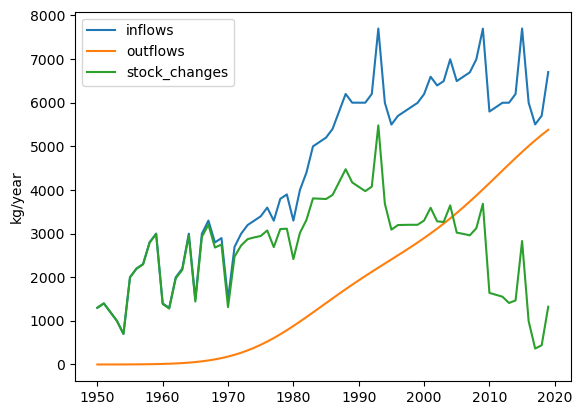

In [5]:
mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

# Visualize the MFA model
mfa_system[["inflows", "outflows", "stock_changes"]].plot(ylabel=units['flows'])

### 4.2. Option 2: Separating the survival curve matrix calculation

In [6]:
survival_curves_matrix = scipy.linalg.toeplitz(survival_curve, np.zeros(len(survival_curve))) 
mfa_system["inflows"] = np.linalg.solve(survival_curves_matrix, mfa_system['stocks'])

<Axes: ylabel='kg/year'>

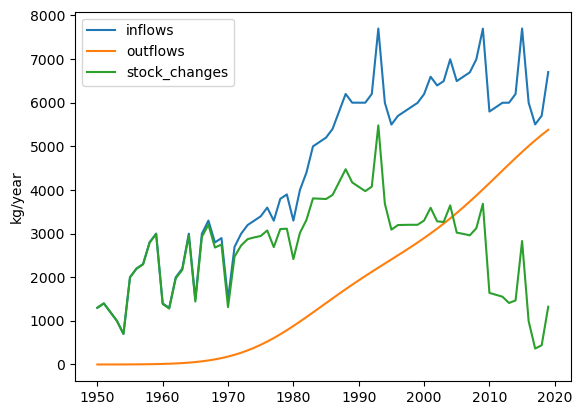

In [7]:
mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

# Visualize the MFA model
mfa_system[["inflows", "outflows", "stock_changes"]].plot(ylabel=units['flows'])